In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
orders = pd.read_csv("../data/processed/orders_clean.csv")
order_items = pd.read_csv("../data/processed/order_items_clean.csv")
payments = pd.read_csv("../data/processed/payments_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
reviews = pd.read_csv("../data/processed/reviews_clean.csv")
sellers = pd.read_csv("../data/processed/sellers_clean.csv")
geolocation = pd.read_csv("../data/processed/geolocation_clean.csv")
category_translation = pd.read_csv("../data/processed/category_translation_clean.csv")

In [5]:
# converting to date time
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [6]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "products": products,
    "reviews": reviews,
    "sellers": sellers
}

for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("Shape:", df.shape)

CUSTOMERS
Shape: (99441, 5)
ORDERS
Shape: (99441, 8)
ORDER_ITEMS
Shape: (112650, 7)
PAYMENTS
Shape: (103886, 5)
PRODUCTS
Shape: (32951, 9)
REVIEWS
Shape: (99224, 7)
SELLERS
Shape: (3095, 4)


## 1. Order Status Distribution

### Business Question
What proportion of orders were delivered, cancelled, shipped, or left in another status?

### Why this matters
Order status distribution gives a quick overview of operational performance.

A high percentage of delivered orders indicates that most transactions were completed successfully. Cancelled, unavailable, or unfinished orders may highlight fulfilment or inventory issues.

In [7]:
order_status_counts = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status_counts.columns = ["order_status", "total_orders"]

order_status_counts

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [8]:
order_status_counts["percentage"] = (
    order_status_counts["total_orders"]
    / order_status_counts["total_orders"].sum()
    * 100
).round(2)

order_status_counts

,order_status,total_orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


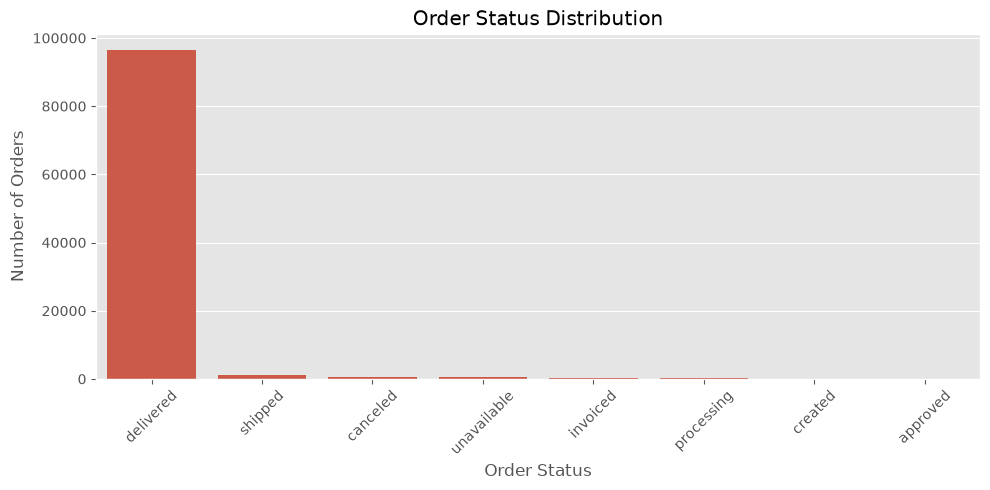

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=order_status_counts,
    x="order_status",
    y="total_orders"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Findings

- The large majority of orders were successfully delivered.
- Delivered orders account for approximately 97% of all orders.
- Shipped orders represent orders that had not yet reached the customer when the dataset was collected.
- Cancelled and unavailable orders represent a small percentage of total orders.
- Overall, the order fulfilment rate appears strong, although cancelled and unavailable orders could be investigated further.

## 2. Monthly Order Trend

### Business Question
How did the number of orders change over time?

### Why this matters
Monthly order trends help identify business growth, seasonal patterns, unusual drops, and periods of high customer activity.

In [ ]:

monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")["order_id"] # grouping by month end
    .nunique()
    .reset_index()
)

monthly_orders.columns = ["month", "total_orders"]

monthly_orders.head()

,month,total_orders
0,2016-09-30,4
1,2016-10-31,324
2,2016-11-30,0
3,2016-12-31,1
4,2017-01-31,800


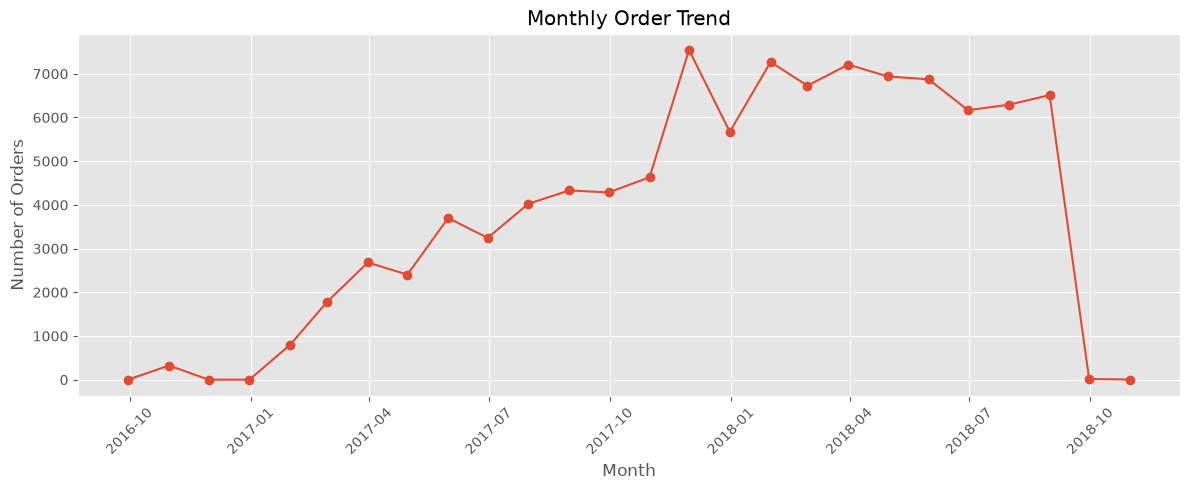

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["month"],
    monthly_orders["total_orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Monthly Revenue Trend

### Business Question
How did product revenue change over time?

### Why this matters
Monthly revenue trends help measure business growth and identify high-performing or unusually weak periods.

In the Olist dataset, each row in `order_items` represents one purchased item. Therefore, summing the `price` column gives the total product revenue for those item records.

In [15]:
monthly_revenue = (
    orders[["order_id", "order_purchase_timestamp", "order_status"]]
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="inner"
    )
)

monthly_revenue = monthly_revenue[
    monthly_revenue["order_status"] == "delivered"
]

monthly_revenue = (
    monthly_revenue
    .set_index("order_purchase_timestamp")
    .resample("ME")["price"]
    .sum()
    .reset_index()
)

monthly_revenue.columns = ["month", "revenue"]

monthly_revenue.head()

,month,revenue
0,2016-09-30,134.97
1,2016-10-31,40325.11
2,2016-11-30,0.00
3,2016-12-31,10.90
4,2017-01-31,111798.36


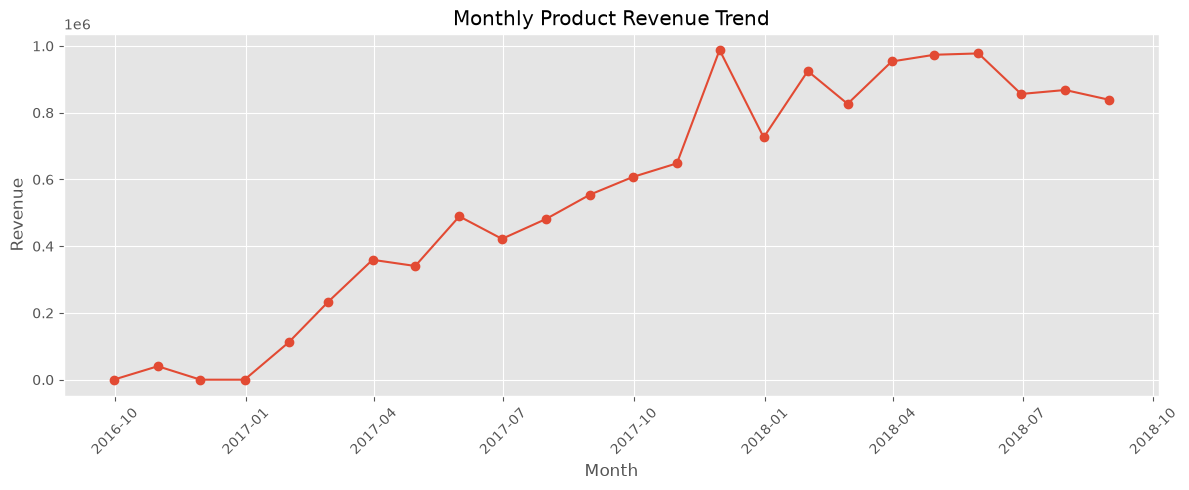

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Product Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Findings

- Product revenue increased considerably during 2017, following a pattern similar to monthly order growth.
- Revenue reached one of its strongest levels around the end of 2017, which may reflect seasonal shopping and promotional activity.
- Revenue remained relatively high during much of 2018.
- Differences between the order-volume and revenue trends may indicate changes in the average value of items purchased.
- The first and last months should be interpreted carefully because they may contain incomplete data.
- Overall, the revenue trend suggests substantial business expansion over the observed period.

## 4. Top Product Categories by Revenue

### Business Question
Which product categories generate the highest product revenue?

### Why this matters
This analysis helps identify the categories that contribute most to sales performance.

It can support decisions related to inventory planning, promotions, seller partnerships, and category-level marketing.

In [17]:
category_revenue = (
    order_items[["product_id", "price"]]
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)
# filling missing category name from portugese to english
category_revenue["product_category_name_english"] = (
    category_revenue["product_category_name_english"]
    .fillna(category_revenue["product_category_name"])
)

top_categories = (
    category_revenue
    .groupby("product_category_name_english", as_index=False)["price"]
    .sum()
    .sort_values("price", ascending=False)
    .head(10)
)

top_categories.columns = ["product_category", "revenue"]

top_categories

,product_category,revenue
43,health_beauty,1258681.34
72,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
67,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


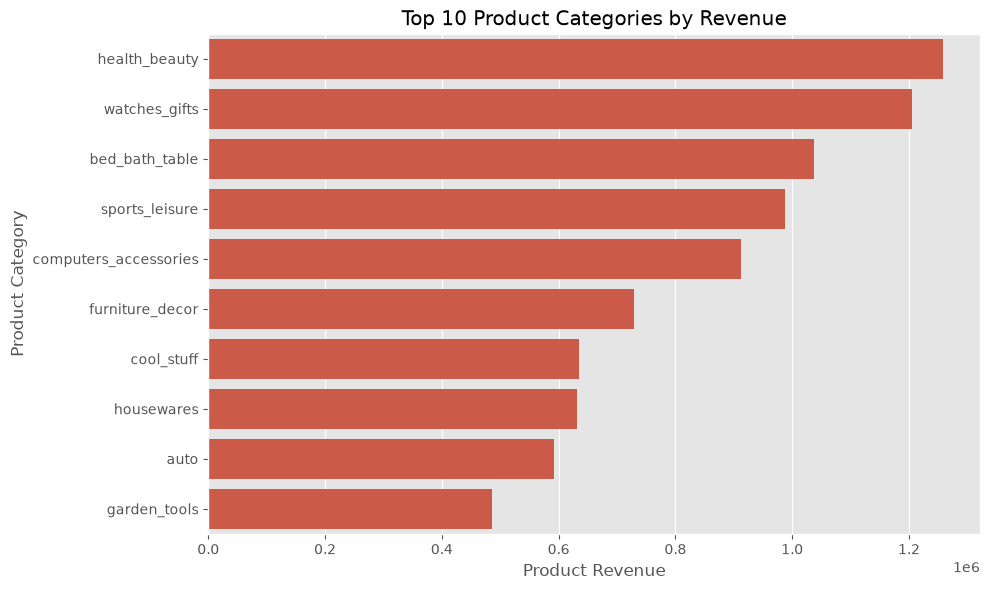

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_categories,
    x="revenue",
    y="product_category"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## 5. Top States by Revenue

### Business Question
Which customer states generate the highest product revenue?

### Why this matters
This analysis helps identify the strongest geographical markets.

The result can support regional marketing, logistics planning, and customer acquisition strategies.

In [19]:
state_revenue = (
    orders[["order_id", "customer_id", "order_status"]]
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="inner"
    )
)

state_revenue = state_revenue[
    state_revenue["order_status"] == "delivered"
]

state_revenue.head()

,order_id,customer_id,order_status,customer_state,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,SP,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,BA,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,GO,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,RN,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,SP,19.90


In [22]:
top_states = (
    state_revenue
    .groupby("customer_state", as_index=False)["price"]
    .sum()
    .sort_values("price", ascending=False)
    .head(10)
)
top_states.columns = ["customer_state", "revenue"]

top_states.head()

,customer_state,revenue
25,SP,5067633.16
18,RJ,1759651.13
10,MG,1552481.83
22,RS,728897.47
17,PR,666063.51


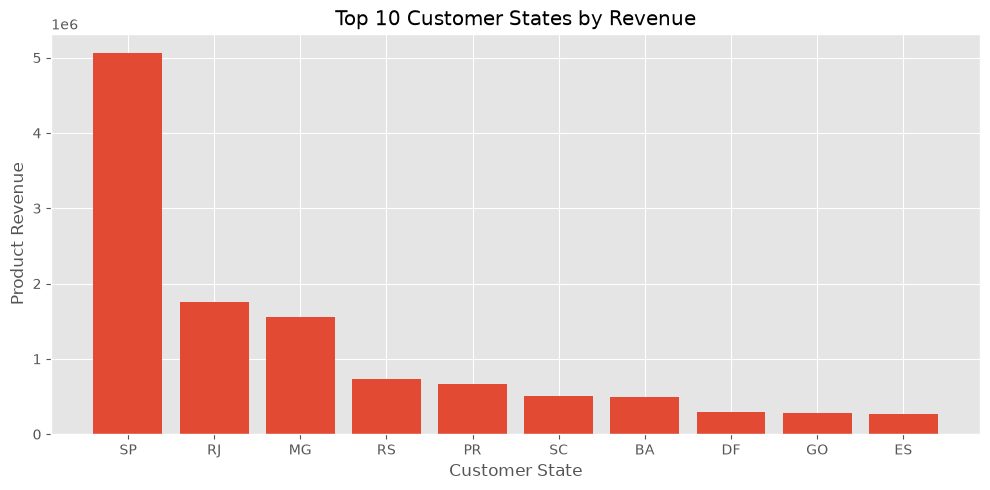

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_states["customer_state"],
    top_states["revenue"]
)

plt.title("Top 10 Customer States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Product Revenue")
plt.tight_layout()
plt.show()

In [42]:
state_city_reference = (
    geolocation
    .groupby("geolocation_state")["geolocation_city"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

state_city_reference.columns = ["State", "Most Frequent City"]


In [43]:
state_names = {
    "AC": "Acre",
    "AL": "Alagoas",
    "AP": "Amapa",
    "AM": "Amazonas",
    "BA": "Bahia",
    "CE": "Ceara",
    "DF": "Distrito Federal",
    "ES": "Espirito Santo",
    "GO": "Goias",
    "MA": "Maranhao",
    "MT": "Mato Grosso",
    "MS": "Mato Grosso do Sul",
    "MG": "Minas Gerais",
    "PA": "Para",
    "PB": "Paraiba",
    "PR": "Parana",
    "PE": "Pernambuco",
    "PI": "Piaui",
    "RJ": "Rio de Janeiro",
    "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul",
    "RO": "Rondonia",
    "RR": "Roraima",
    "SC": "Santa Catarina",
    "SP": "Sao Paulo",
    "SE": "Sergipe",
    "TO": "Tocantins"
}

In [46]:
state_city_reference["State Name"] = (
    state_city_reference["State"].map(state_names)
)

state_city_reference[["State","State Name","Most Frequent City"]]

,State,State Name,Most Frequent City
0,AC,Acre,rio branco
1,AL,Alagoas,maceio
2,AM,Amazonas,manaus
3,AP,Amapa,macapa
4,BA,Bahia,salvador
5,CE,Ceara,fortaleza
6,DF,Distrito Federal,brasilia
7,ES,Espirito Santo,vitoria
8,GO,Goias,goiania
9,MA,Maranhao,sao luis


## 6. Customer Review Score Distribution

### Business Question
How satisfied are customers with their purchases?

### Why this matters
Customer review scores provide a direct measure of customer satisfaction.

A high proportion of 4- and 5-star reviews generally indicates positive customer experiences, while lower ratings may highlight issues with products, delivery, or service quality.

In [47]:
review_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_counts.columns = ["review_score", "total_reviews"]

review_counts

,review_score,total_reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


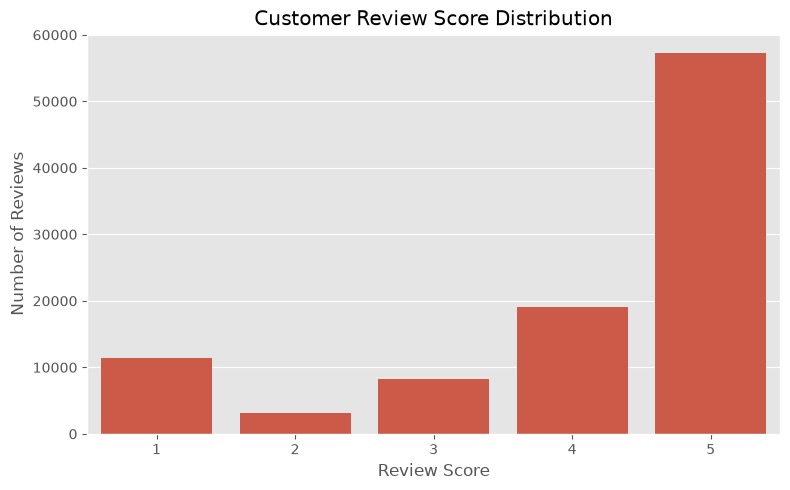

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=review_counts,
    x="review_score",
    y="total_reviews"
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()